In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv("student_data.csv")

# Features & target
X = data.drop("passed", axis=1)
y = data["passed"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

data=pd.read_csv("Diabetes main dataset.csv")


x=data.drop("Outcome", axis=1)
y=data["Outcome"]


ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['gender','smoking_history'])
    ],
    remainder='passthrough'
)

x = ct.fit_transform(x)


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model=LogisticRegression(max_iter=100000)
model.fit(x_train,y_train)

predictions=model.predict(x_test)

l=model.score(x_test,y_test)
print("Diabetes:",l)

Diabetes: 0.5558068474364218



===== Logistic Regression =====
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.80      0.72      8048
           1       0.53      0.34      0.42      5245

    accuracy                           0.62     13293
   macro avg       0.59      0.57      0.57     13293
weighted avg       0.60      0.62      0.60     13293

Confusion Matrix:
[[6470 1578]
 [3449 1796]]

===== KNN =====
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8048
           1       0.99      0.98      0.98      5245

    accuracy                           0.99     13293
   macro avg       0.99      0.99      0.99     13293
weighted avg       0.99      0.99      0.99     13293

Confusion Matrix:
[[7975   73]
 [  87 5158]]

===== Linear SVM =====
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      8048
    

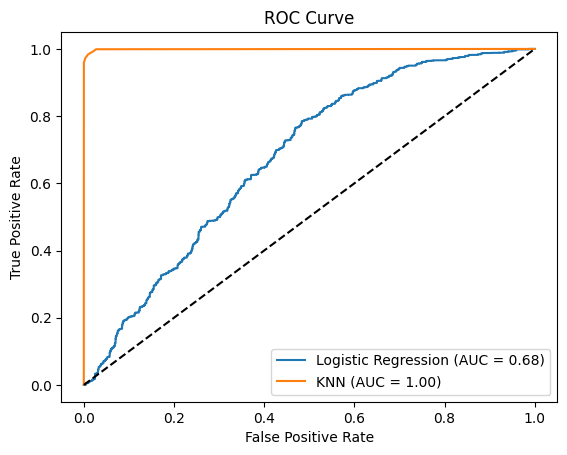

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df=pd.read_csv("Diabetes main dataset.csv")


df = df.drop_duplicates()

df = df.drop(columns=['diabetes', 'Age'], errors='ignore')


le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


X = df.drop('Outcome', axis=1)
y = df['Outcome']


cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'bmi']
X[cols_with_zero] = X[cols_with_zero].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X_scaled, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Linear SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)



for name, model in models.items():
    print(f"\n===== {name} =====")
    
    y_pred = model.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):  
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()